##Contents

0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

# 0. Learning Objectives


*   Application of  **Naive Bayes Classifier** on a public dataset


#1. Tutorial Details

*   **ML Topic(s) Covered**: Naive Bayes Classifier
*   **Problem Statement**: The Wine recognition dataset contains the results of a chemical analysis of wines grown in the same region in Italy, but derived from three different cultivars. It contains 178 rows and 14 columns, with each row representing a wine sample and each column representing an attribute of that sample. The goal is to apply Naive Bayes Classification to predict the type of wine based on its chemical properties.
*   Approximate model training time: 5-10 min.

#2. Problem Statement Description

*   **Objective**: To predict the type of wine based on the features using Naive Bayes Classificaiton algorithm.
*   **Data Description**: The Wine recognition dataset is a well-known dataset in the field of machine learning and is often used for classification tasks. It contains the results of a chemical analysis of wines grown in the same region in Italy, but derived from three different cultivars. The analysis determined the quantities of 13 different constituents found in each of the three types of wines.

 *  The dataset contains 178 rows and 14 columns, with each row representing a wine sample and each column representing an attribute of that sample. The first column is the class label, which represents the type of wine, and the remaining 13 columns are the attributes, which represent the results of the chemical analysis.

  * The three classes in the dataset correspond to three different types of wine:
      *   Class 0 represents the first cultivar (59 samples)
      *   Class 1 represents the second cultivar (71 samples)
      *   Class 2 represents the third cultivar (48 samples)
  * The 13 attributes in the dataset are:
      * Alcohol
      * Malic acid
      * Ash
      * Alcalinity of ash
      * Magnesium
      * Total phenols
      * Flavanoids
      * Nonflavanoid phenols
      * Proanthocyanins
      * Color intensity
      * Hue
      * OD280/OD315 of diluted wines
      * Proline

*   More information is available here: https://archive.ics.uci.edu/ml/datasets/wine

# 3. Import Packages

Package versions

*   pandas==1.4.4
*   numpy==1.22.4
*   matplotlib==3.7.1
*   sklearn==1.2.2

In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# Scikit-learn (sklearn) contains functions of machine learning models, evaluation metrics, helper functions and datasets
import sklearn

# 4. Load and Prepare the Dataset

In [2]:
# Load the Wine Recognition dataset
from sklearn.datasets import load_wine
# Load the Wine Recognition dataset
data = load_wine()

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target_names[data.target]

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


We have 13 features followed by 1 target variable.

In [3]:
#Print the shape of the data
df.shape

(178, 14)


There are 14 columns (13 features and 1 target variable) and 178 rows in the imported data.


In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

*   All features are float values.
*   The target variable is of object (categorical type). This needs to be converted to some numerical value.
*   There is no null value.



Below, let us separate the feature (independent variable) and the target variable (dependent variable) in the data.


In [5]:
features = df.iloc[:, :-1]
predictions = df.iloc[:, -1] #Last column contains the target variable

In [6]:
#Print a fews rows of independent variables
features.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
#Print a fews rows of dependent variables
predictions.head()

0    class_0
1    class_0
2    class_0
3    class_0
4    class_0
Name: target, dtype: object

### Feature Scaling
Let's perform feature standardization

In [8]:
# Perform feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #Used to perform standardization of the features
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns = features.columns)
features_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


Now the range of each feature has been drastically reduced to vary around zero.

Below, let us divided into the training and testing data.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, predictions, test_size=0.2, random_state=0, shuffle=True)
#20% of the total data is kept as test data

# 5.   Peform Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is a crucial step in understanding and analyzing any dataset.

Henceforth, all the analysis will be performed on the train dataset only. Assume that we do not possess the test data.

In [10]:
Train_data = pd.concat([X_train, y_train], axis = 'columns') #Join along the columns
Train_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
161,0.851569,0.829128,0.634140,0.151661,0.509638,-0.745264,-1.475098,1.113154,-1.385721,0.355534,0.011190,-1.118210,-0.213021,class_2
92,-0.383696,-0.723829,-0.389355,0.361860,-1.386122,-1.466313,-0.571528,1.757779,0.050988,-0.868639,0.011190,-0.779224,-0.802153,class_1
94,-1.705429,-0.310904,-0.316249,-0.448909,-0.122282,1.161510,0.231646,-1.545922,-0.422075,-0.782125,0.888658,0.491974,-1.279827,class_1
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,class_2
24,0.616869,-0.472483,0.890014,0.151661,-0.262708,0.376368,0.583034,-0.659563,0.121071,-0.665332,0.713164,1.706675,0.312420,class_0


In [11]:
#Print summary statistics
Train_data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,-0.019466,0.032547,0.001406,0.018013,0.022595,-0.058406,-0.080433,0.013434,0.026557,-0.005571,-0.017976,-0.035901,-0.014529
std,0.997075,1.001218,0.985786,1.033746,1.000481,0.980132,0.979792,1.029052,1.035868,1.029695,1.008725,1.020691,0.967401
min,-2.434235,-1.432983,-3.679162,-2.671018,-2.088255,-1.914966,-1.565455,-1.868234,-2.051513,-1.634288,-1.831492,-1.895054,-1.454974
25%,-0.806774,-0.658749,-0.526431,-0.674123,-0.754202,-0.945556,-0.995704,-0.740141,-0.610424,-0.845929,-0.778531,-1.040526,-0.750404
50%,0.048647,-0.396182,-0.023821,0.001518,-0.122282,-0.136378,0.005753,-0.176095,-0.062898,-0.198156,0.011190,0.209486,-0.228944
75%,0.786718,0.795466,0.707247,0.602088,0.492085,0.704846,0.733629,0.710264,0.642316,0.526399,0.713164,0.785056,0.591860
max,2.160950,2.974543,3.119772,3.154511,4.371372,2.539515,1.717516,2.402403,3.485073,3.435432,3.301694,1.960915,2.547935


It is difficult for us to explore each column through statistics. We will utilize box plots in such a case.

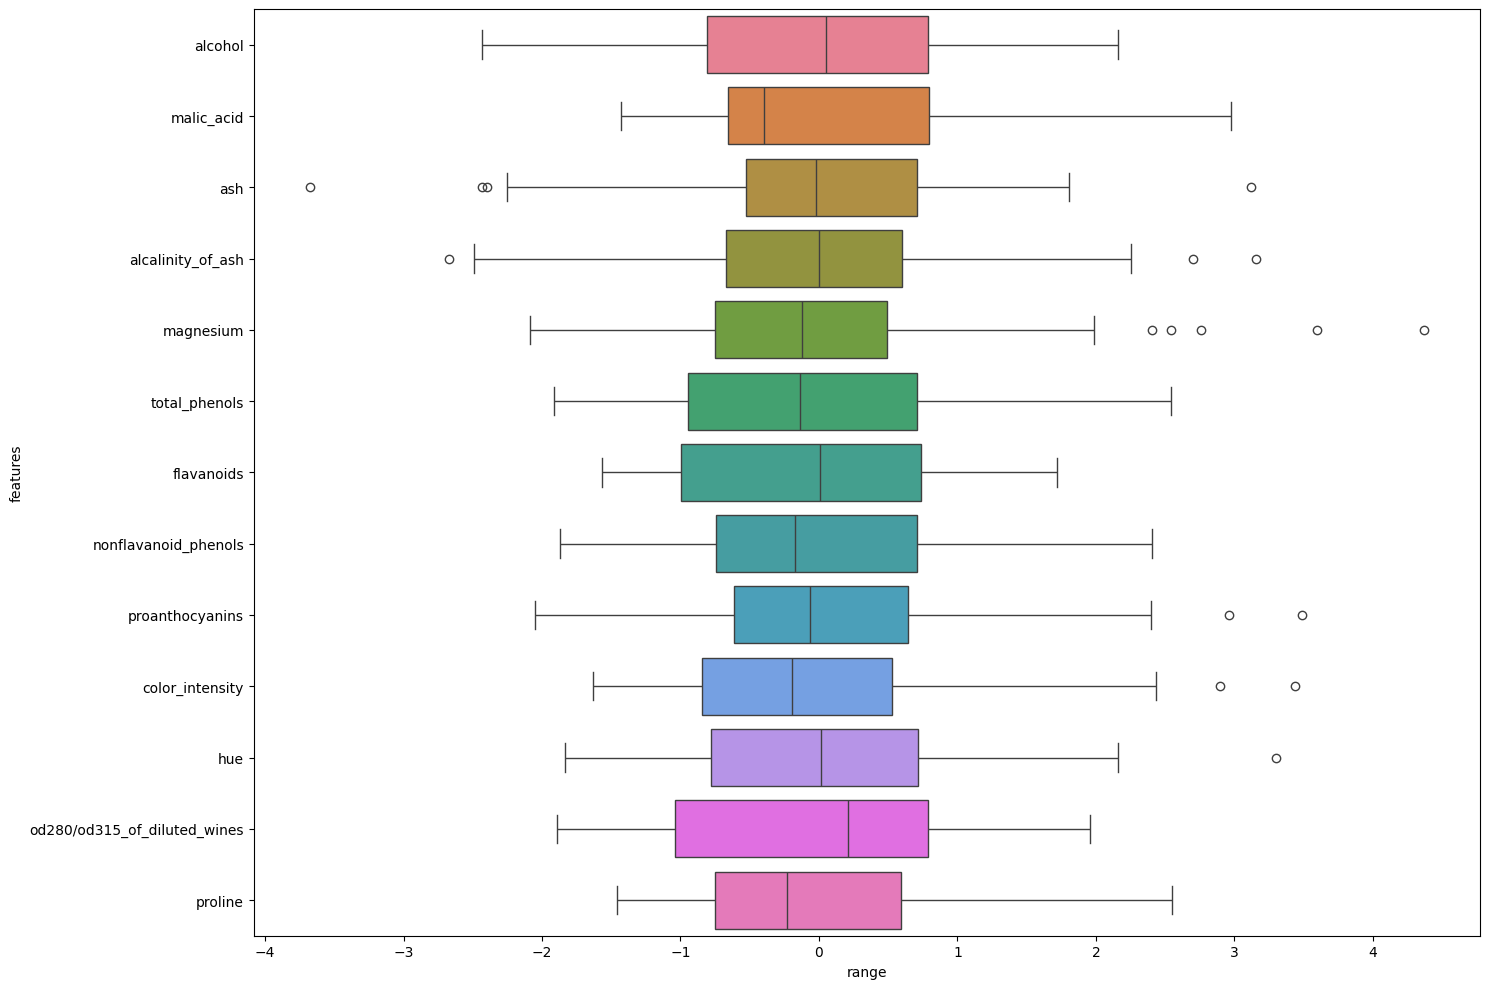

In [12]:
# Seaborn is a data visualization library based on matplotlib
import seaborn as sns
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(data=X_train, orient="h").set(xlabel= 'range', ylabel='features')
plt.tight_layout()

There are some outliers that may be treated (**Try it Yourself!**).

# Distribution of each feature by target variable
The boxplot can also be used to review the distribution of each feature by target variable. This may give us interesting insights.

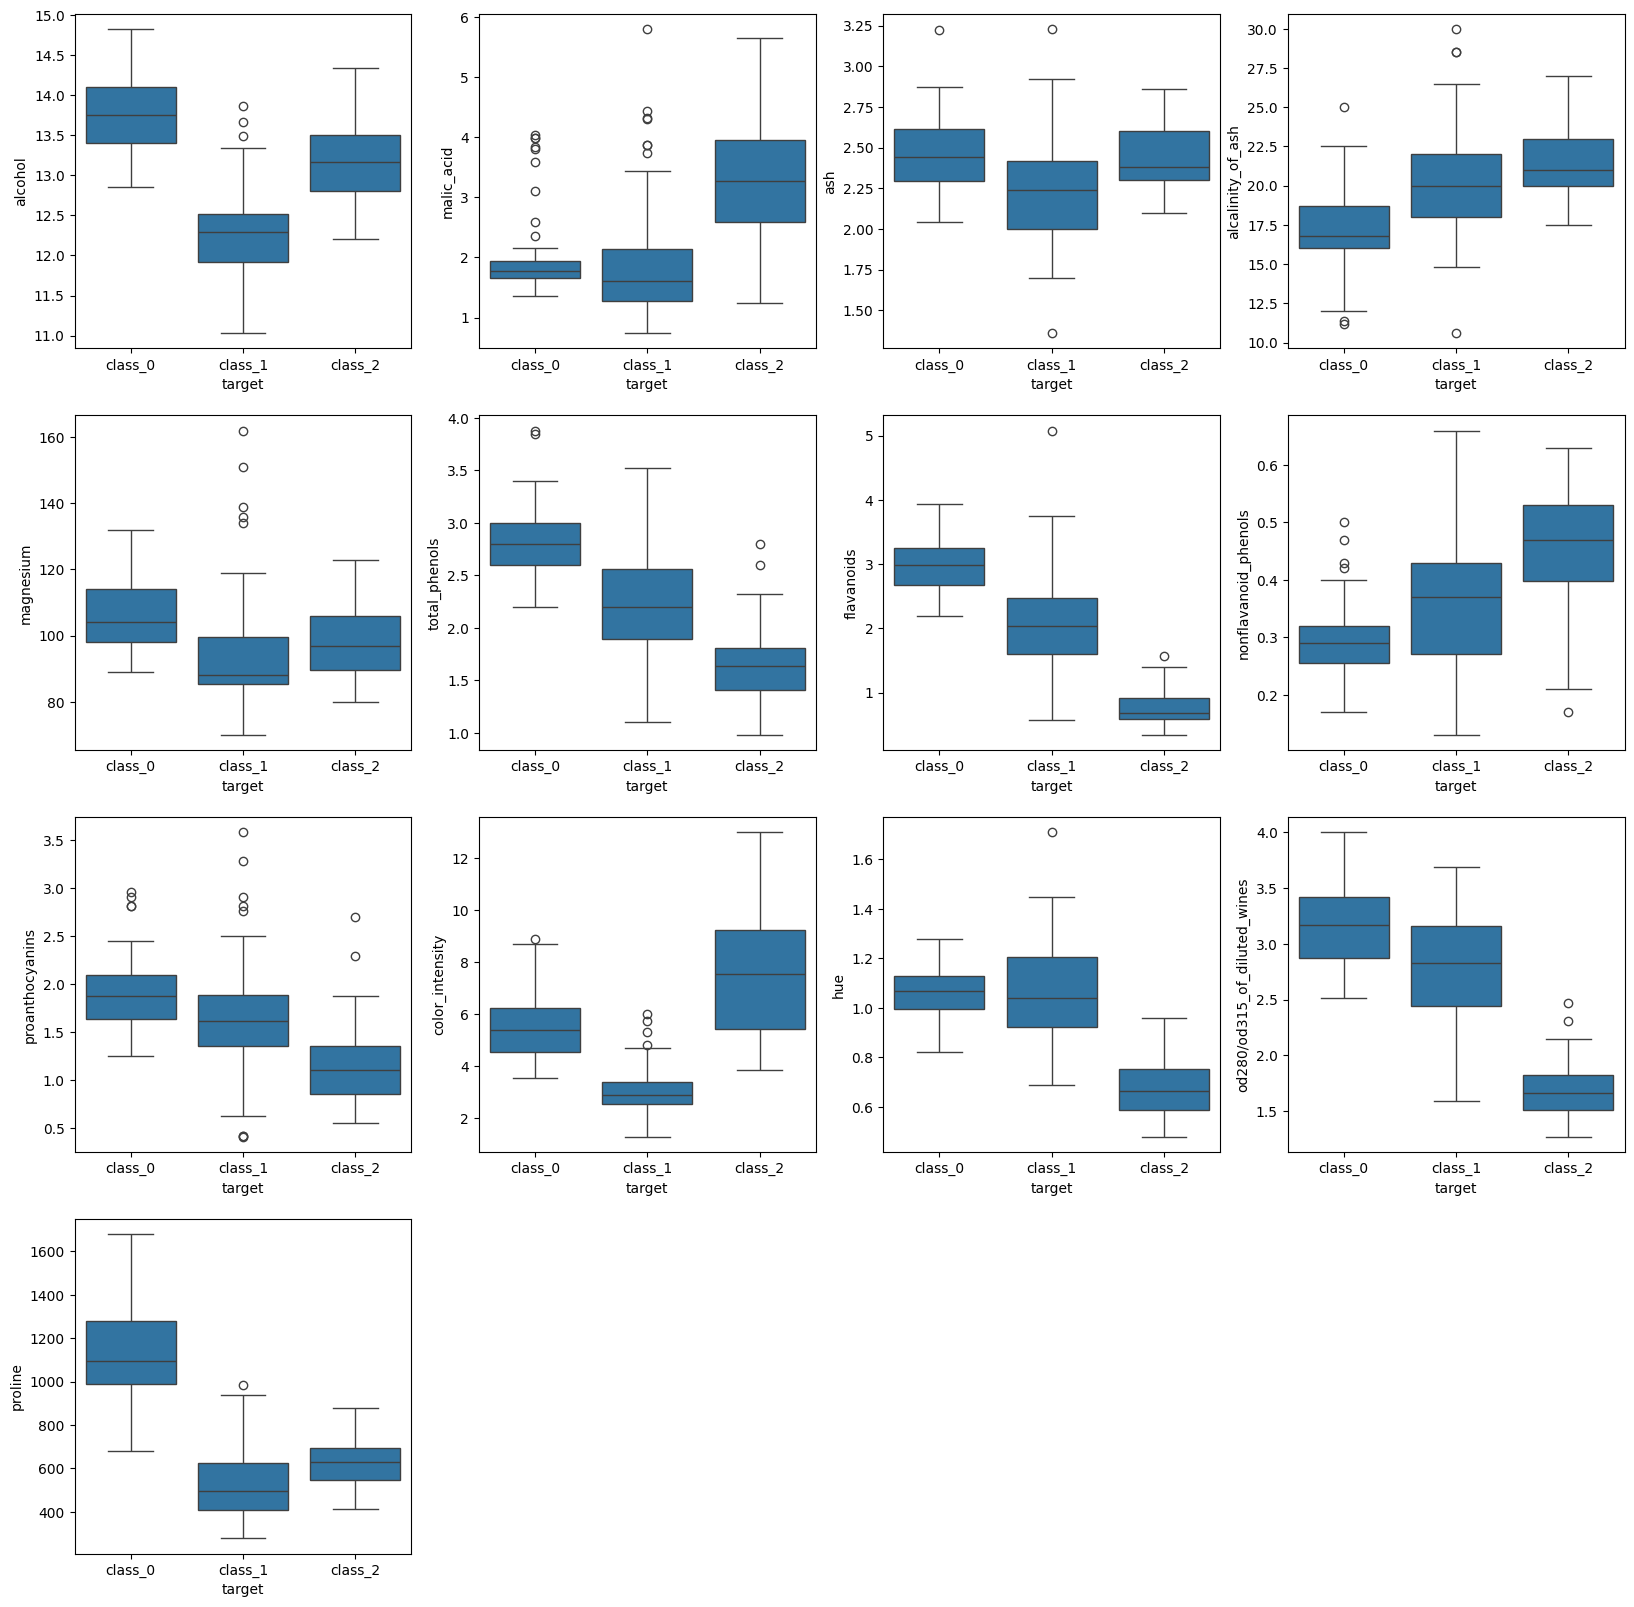

In [13]:
# View the distribution of each feature by target variable
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 13:
        sns.boxplot(data=df, x='target', y=df.columns[i], ax=ax)
    else:
        ax.set_visible(False)
plt.show()


*   The *flavanoids* attribute clearly distinguished the three classes. The class 0 has high flavanoids, while class 2 has low value of flavanoids.
*   Similar characteristic appears in the *total_phenols* attribute.
*   For the *nonflavanoid_phenols*, this characteristic is reversed, i.e., high value for class 2 and low value for class 1.
*   Using *hue*, one may distinguish between class 2 vs class 0 & 1 combined. The hue value for class 2 os extremly low compared to the other two classes.

These insights can help the model make a better choice for the feature selection. Here, we will use all the features. However, one the model is trained, one may come back to experiment with the choice of features.

### Correlation Analysis

In [14]:
#Perform correlation analysis between numerical features
corr_mat = Train_data.corr(method ='pearson') #Pearson correlation is used
corr_mat

<ipython-input-14-9a44fb0c6ab7>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_mat = Train_data.corr(method ='pearson') #Pearson correlation is used


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.100874,0.266207,-0.273232,0.235365,0.314484,0.276553,-0.100155,0.129632,0.566025,-0.067541,0.057073,0.619813
malic_acid,0.100874,1.000000,0.173466,0.266779,-0.031623,-0.322541,-0.417179,0.330698,-0.219270,0.302503,-0.541480,-0.391111,-0.186186
ash,0.266207,0.173466,1.000000,0.445968,0.201369,0.160595,0.093388,0.158221,0.017448,0.261122,-0.094603,-0.011545,0.190943
alcalinity_of_ash,-0.273232,0.266779,0.445968,1.000000,-0.100902,-0.325718,-0.399852,0.386218,-0.215529,0.012670,-0.252494,-0.298203,-0.432653
magnesium,0.235365,-0.031623,0.201369,-0.100902,1.000000,0.182268,0.165807,-0.310549,0.260233,0.151305,0.042404,0.029867,0.339024
total_phenols,0.314484,-0.322541,0.160595,-0.325718,0.182268,1.000000,0.858048,-0.454415,0.622975,-0.062106,0.452515,0.709367,0.528110
flavanoids,0.276553,-0.417179,0.093388,-0.399852,0.165807,0.858048,1.000000,-0.576292,0.662524,-0.204740,0.587220,0.797165,0.539812
nonflavanoid_phenols,-0.100155,0.330698,0.158221,0.386218,-0.310549,-0.454415,-0.576292,1.000000,-0.323831,0.192717,-0.328522,-0.509848,-0.330599
proanthocyanins,0.129632,-0.219270,0.017448,-0.215529,0.260233,0.622975,0.662524,-0.323831,1.000000,-0.031313,0.310292,0.505636,0.352720
color_intensity,0.566025,0.302503,0.261122,0.012670,0.151305,-0.062106,-0.204740,0.192717,-0.031313,1.000000,-0.545881,-0.453062,0.309687


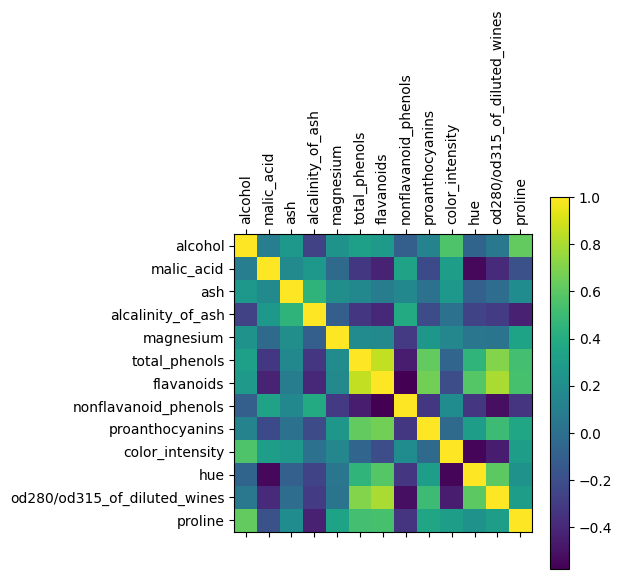

In [15]:
# Visualize the correlation matrix
plt.matshow(corr_mat)
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
plt.colorbar()
plt.show()



*   The *flavanoids* and *total_phenol* have high correlation 0.85. One may drop one of the two columns to reduce dimensionality.
*   The *flavanoids* attribute has 0.80 correlation with *od280/od315_of_diluted_wines* attribute. One of the two columns can be dropped.

There is no other significant information from the correlation matrix.

Based on the above observations, we drop *flavanoids* attribute.

In [14]:
Train_data.drop(['flavanoids'], axis=1, inplace=True)
X_train.drop(['flavanoids'], axis=1, inplace=True)
X_test.drop(['flavanoids'], axis=1, inplace=True)

#6.   Model Building: Training and Testing

Let us define a Naive Bayes model to perform the given classification task.

In [15]:
#Import Gaussian Naive Bayes Classifier class
from sklearn.naive_bayes import GaussianNB
model = GaussianNB() #Define an object of Gaussian Naive Bayes Classifier class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

Notice the 'Gaussian' Naive Bayes Classifier.

Since Naive Bayes is a generative model it assumes some distribution of each class. In current case, the assumption is that each class follows a Gaussian distribution.

#7.   Results and Interpretation

In [16]:
from sklearn.metrics import f1_score, confusion_matrix

# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, average='weighted')
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, average='weighted')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.986
Train confusion matrix: 
 [[44  1  0]
 [ 0 54  1]
 [ 0  0 42]]
Test F1 score:  0.973
Test confusion matrix: 
 [[14  0  0]
 [ 0 15  1]
 [ 0  0  6]]


# 8. Conclusion

The three class Naive Bayes Classifier has been trained with a test F1 score of 0.973.

# 9.   Try it yourself excercise


*   **Problem Statement**: Perform Naive Bayes-based classification to predict the age of the abalone using the available data.

*   **Task**: Abalone is an endangered shellfish. The goal of the dataset is to predict the age of the abalone (in years) based on the other attributes. The number of rings in the shell of an abalone is a good indicator of its age, and is typically determined through a tedious process of cutting the shell and counting the rings. The dataset provides a more efficient way of estimating the age of abalone using non-invasive measurements.

    *   Number of Instances: 4,177
    *   Number of Attributes: 8
    *   Attribute Information:
        *   Sex: nominal - M, F, and I (infant)
        *   Length: continuous - longest shell measurement (in mm)
        *   Diameter: continuous - perpendicular to length (in mm)
        *   Height: continuous - with meat in shell (in mm)
        *   Whole weight: continuous - whole abalone (in grams)
        *   Shucked weight: continuous - weight of meat (in grams)
        *   Viscera weight: continuous - gut weight (after bleeding) (in grams)
        *   Shell weight: continuous - after being dried (in grams)
        *   Rings: integer - +1.5 gives the age in years (the target variable)


*  **Source**:  https://archive.ics.uci.edu/ml/datasets/abalone


In [19]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight", "Rings"]
abalone_df = pd.read_csv(url, header=None, names=columns)
abalone_df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Notice that the target variable (Ring) is directly proportional to the age of the abalone. Divide the data into three groups:


*   child: 0 to 5 rings
*   adolescent: 6 to 15 rings
*   adult: above 15 rings

The distribution of the rings is visulaized below.


[]

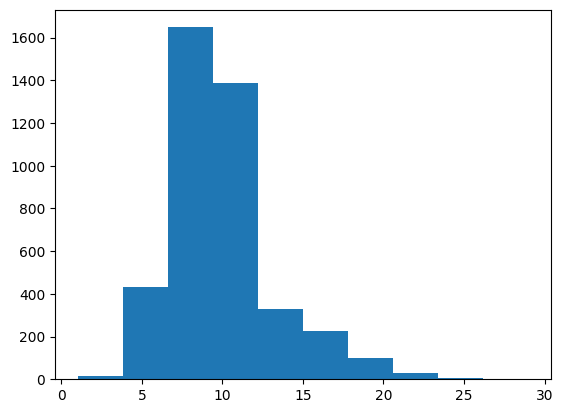

In [20]:
plt.hist(abalone_df['Rings'])
plt.plot()

# 10. Summary

*  To apply **Naive Bayes Classificaiton** over a public dataset